In [1]:
student = {'name': 'Suraj', 'course': 'MT'}
student.update({'speed':45})

In [2]:
student

{'name': 'Suraj', 'course': 'MT', 'speed': 45}

### df[(df['speed'] > 40) & (df['course'] == 'Steno')]. This is the way to use filter in pandas dataframe

In [3]:
import pandas as pd

# JTI Dummy Data
data = {
    'Student_Name': ['Suraj', 'Deepti', 'Sanjit', 'Rakesh', 'Padmini'],
    'Course': ['Steno', 'MT', 'Steno', 'Typing', 'MT'],
    'Speed_WPM': [102, 45, 114, 41, 44],
    'Cert_Date': ['2023-05-01', '2022-01-05', '2022-08-02', '2023-06-05', '2023-01-02']
}

df = pd.DataFrame(data)

# Date ko proper format mein convert karne ke liye (taaki sorting theek se ho)
df['Cert_Date'] = pd.to_datetime(df['Cert_Date'])

print(df)

  Student_Name  Course  Speed_WPM  Cert_Date
0        Suraj   Steno        102 2023-05-01
1       Deepti      MT         45 2022-01-05
2       Sanjit   Steno        114 2022-08-02
3       Rakesh  Typing         41 2023-06-05
4      Padmini      MT         44 2023-01-02


In [4]:
df

,Student_Name,Course,Speed_WPM,Cert_Date
0,Suraj,Steno,102,2023-05-01
1,Deepti,MT,45,2022-01-05
2,Sanjit,Steno,114,2022-08-02
3,Rakesh,Typing,41,2023-06-05
4,Padmini,MT,44,2023-01-02


In [6]:
from pandasql import sqldf

### Revision 

In [7]:
import pandas as pd
from pandasql import sqldf

# Dummy Data 1: Students
df_students = pd.DataFrame({
    'Student_ID': [1, 2, 3, 4],
    'Name': ['Suraj', 'Deepti', 'Sanjit', 'Rakesh'],
    'Course': ['Steno', 'MT', 'Steno', 'Typing']
})

# Dummy Data 2: Fees Paid
df_fees = pd.DataFrame({
    'Student_ID': [1, 2, 4],  # Note: Sanjit (ID 3) hasn't paid yet
    'Amount': [1000, 750, 500]
})

In [8]:
df_students

,Student_ID,Name,Course
0,1,Suraj,Steno
1,2,Deepti,MT
2,3,Sanjit,Steno
3,4,Rakesh,Typing


In [9]:
df_fees

,Student_ID,Amount
0,1,1000
1,2,750
2,4,500


In [12]:
a=pd.merge(df_students,df_fees,how='left')
a

,Student_ID,Name,Course,Amount
0,1,Suraj,Steno,1000.0
1,2,Deepti,MT,750.0
2,3,Sanjit,Steno,NaN
3,4,Rakesh,Typing,500.0


In [14]:
a.groupby('Course')['Amount'].sum()

Course
MT         750.0
Steno     1000.0
Typing     500.0
Name: Amount, dtype: float64

In [18]:
k="""

WITH Steno_Students AS (
    SELECT Name,Student_Id,Course FROM df_students WHERE Course = 'Steno'
)
SELECT * FROM Steno_Students;
"""
sqldf(k)

,Name,Student_Id,Course
0,Suraj,1,Steno
1,Sanjit,3,Steno


In [23]:
speeds = {'Suraj': 45, 'Deepti': 38, 'Sanjit': 50}
a={p:v for p,v in speeds.items() if v>40}

In [24]:
a

{'Suraj': 45, 'Sanjit': 50}

# 10/05/26 mix drill

In [8]:
import numpy as np
import pandas as pd

In [9]:
marks = [40, 50, 60]

In [10]:
np.std(marks)

8.16496580927726

In [32]:
pd.Series.std(marks)

AttributeError: 'list' object has no attribute '_stat_function_ddof'

In [12]:
import pandas as pd
data = {
    'Course': ['Steno', 'MT', 'Steno', 'Typing', 'MT', 'Typing'],
    'Speed': [45, 38, 50, 42, 40, 55],
    'Fees_Status': ['Paid', 'Pending', 'Paid', 'Paid', 'Pending', 'Paid']
}
df = pd.DataFrame(data)

In [13]:
df

,Course,Speed,Fees_Status
0,Steno,45,Paid
1,MT,38,Pending
2,Steno,50,Paid
3,Typing,42,Paid
4,MT,40,Pending
5,Typing,55,Paid


In [33]:
df[df['Fees_Status'] == 'Paid'].groupby('Course')['Speed'].mean()

Course
Steno     47.5
Typing    48.5
Name: Speed, dtype: float64

In [21]:
speeds = [25, 45, 60, 32, 55]
a=pd.DataFrame(speeds)
a

,0
0,25
1,45
2,60
3,32
4,55


In [34]:
a['Check_speeds']=a[0].apply(lambda x: 'Fast' if x>40 else 'Slow')

In [35]:
a

,0,Check_speeds
0,25,Slow
1,45,Fast
2,60,Fast
3,32,Slow
4,55,Fast


In [36]:
arr = [10, 20, 30, 40, 50]
np.std(arr,ddof=1)

15.811388300841896

In [44]:
x=48
std=5
mean=40
z_Score=(x-mean)/std
z_Score

1.6

In [24]:
raw_data = {'ID': [1, 2, 2, 4], 'Val': [10, 20, 20, None]}
raw=pd.DataFrame(raw_data)

In [25]:
raw

,ID,Val
0,1,10.0
1,2,20.0
2,2,20.0
3,4,NaN


In [27]:
raw.drop_duplicates(inplace=True)

In [28]:
raw

,ID,Val
0,1,10.0
1,2,20.0
3,4,NaN


In [59]:
raw.fillna((0),inplace=True)

In [60]:
raw

,ID,Val
0,1,10.0
1,2,20.0
3,4,0.0


In [37]:
df

,Course,Speed,Fees_Status
0,Steno,45,Paid
1,MT,38,Pending
2,Steno,50,Paid
3,Typing,42,Paid
4,MT,40,Pending
5,Typing,55,Paid


In [41]:
df.groupby('Course')['Speed'].agg(['mean','std'])

,mean,std
Course,,
MT,39.0,1.414214
Steno,47.5,3.535534
Typing,48.5,9.192388


In [42]:
df[(df['Fees_Status']=='Paid')&(df['Speed']>45)]

,Course,Speed,Fees_Status
2,Steno,50,Paid
5,Typing,55,Paid


In [43]:
data = [100, 200, 300, 400]
np.std(data,ddof=1)

129.09944487358058

In [45]:
x=48
std=5
mean=40
z_Score=(x-mean)/std
z_Score

1.6

In [46]:
raw_data = {'A': [1, 2, 2, 4], 'B': [5, 5, 6, None]}
r=pd.DataFrame(raw_data)

In [47]:
r

,A,B
0,1,5.0
1,2,5.0
2,2,6.0
3,4,NaN


In [61]:
r.drop_duplicates(subset=['A'])

,A,B
0,1,5.0
1,2,5.0
3,4,NaN


In [55]:
r

,A,B
0,1,5.0
1,2,5.0
2,2,6.0
3,4,NaN


In [56]:
raw_data = {'A': [1, 2, 2, 4], 'B': [5, 5, 6, None]}

In [58]:
pd.DataFrame(raw_data).drop_duplicates().fillna(0)

,A,B
0,1,5.0
1,2,5.0
2,2,6.0
3,4,0.0


In [62]:
salaries = [20, 22, 25, 21, 150, 23]

In [65]:
a=np.std(salaries)

In [66]:
b=np.mean(salaries)

In [67]:
c=np.median(salaries)

In [68]:
c

22.5

In [69]:
diff=b-c
diff

21.0

In [70]:
df

,Course,Speed,Fees_Status
0,Steno,45,Paid
1,MT,38,Pending
2,Steno,50,Paid
3,Typing,42,Paid
4,MT,40,Pending
5,Typing,55,Paid


In [84]:
df['Rating'] = df['Speed'].apply(lambda x: 'A' if x > 50 else ('B' if x > 40 else 'C'))


In [85]:
df

,Course,Speed,Fees_Status,Rating
0,Steno,45,Paid,B
1,MT,38,Pending,C
2,Steno,50,Paid,B
3,Typing,42,Paid,B
4,MT,40,Pending,C
5,Typing,55,Paid,A


In [72]:
from scipy import stats

In [73]:
data = [1, 2, 2, 3, 100]

In [74]:
stats.zscore(data)

array([-0.52544182, -0.49993494, -0.49993494, -0.47442805,  1.99973974])

In [86]:
dates = ['2026-05-01', '2026-05-10']
dt_series = pd.to_datetime(dates)
# Day names nikalo
days = dt_series.day_name()
print(days)

Index(['Friday', 'Sunday'], dtype='object')


In [78]:
k=df[(df['Course']=='Steno')]

In [79]:
k

,Course,Speed,Fees_Status
0,Steno,45,Paid
2,Steno,50,Paid


In [87]:
k['Speed'].std()

3.5355339059327378

In [89]:
df['Status'] = np.where(df['Fees_Status'] == 'Paid', 'Success', 'Alert')

In [90]:
df

,Course,Speed,Fees_Status,Rating,Status
0,Steno,45,Paid,B,Success
1,MT,38,Pending,C,Alert
2,Steno,50,Paid,B,Success
3,Typing,42,Paid,B,Success
4,MT,40,Pending,C,Alert
5,Typing,55,Paid,A,Success


In [91]:
df['Division']=df['Speed'].apply(lambda x: '1st'if x>50 else('2nd'if x>40 else'fail'))

In [92]:
df

,Course,Speed,Fees_Status,Rating,Status,Division
0,Steno,45,Paid,B,Success,2nd
1,MT,38,Pending,C,Alert,fail
2,Steno,50,Paid,B,Success,2nd
3,Typing,42,Paid,B,Success,2nd
4,MT,40,Pending,C,Alert,fail
5,Typing,55,Paid,A,Success,1st


In [93]:
d1 = '2026-05-01'
d2 = '2026-05-10'


In [96]:
a=pd.to_datetime(d1)
a

Timestamp('2026-05-01 00:00:00')

In [97]:
b=pd.to_datetime(d2)
b

Timestamp('2026-05-10 00:00:00')

In [98]:
day5=a.day_name()
day5

'Friday'

In [100]:
day6=b.day_name()
day6

'Sunday'

In [102]:
kp=a-b
kp

Timedelta('-9 days +00:00:00')

In [104]:
df.drop('Rating').rename(columns={'Speed':'WPM'},inplace=True)

KeyError: "['Rating'] not found in axis"

In [107]:
L = [10, None, 20, 'Missing', 30]
p=pd.DataFrame(L)

In [108]:
p

,0
0,10
1,None
2,20
3,Missing
4,30


In [111]:
pd.to_numeric(p,errors='coerce')

TypeError: arg must be a list, tuple, 1-d array, or Series

In [112]:
s = pd.Series([10, None, 20, 'Missing', 30])

In [114]:
import pandas as pd

# 1. Kachra List
L = [10, None, 20, 'Missing', 30]
s = pd.Series(L)

# 2. Pehle numeric mein badlo (kachra NaN ban jayega)
s_numeric = pd.to_numeric(s, errors='coerce')

# 3. Ab s_numeric saaf hai, iska mean nikal kar fill karo
s_final = s_numeric.fillna(s_numeric.mean())

print(s_final)

0    10.0
1    20.0
2    20.0
3    20.0
4    30.0
dtype: float64


In [115]:
import numpy as np
from scipy import stats
data = np.array([10, 12, 14, 15, 100, 12, 11])
z = stats.zscore(data)
clean_data = data[np.abs(z) < 3]

In [116]:
clean_data

array([ 10,  12,  14,  15, 100,  12,  11])

In [117]:
sample = [42, 44, 46, 41, 43, 44, 45, 42, 43, 44]
t_stat, p_val = stats.ttest_1samp(sample, 45)

In [118]:
print(p_val)

0.008380205975900367


In [119]:
Study_Hrs = [1, 2, 3, 4, 5]
Speed = [25, 30, 45, 50, 65]
corr, _ = stats.pearsonr(Study_Hrs, Speed)
print(corr)

0.985329278164293


In [120]:
WPM = [45, 48, 50, 52, 55, 120]
_ , p_norm = stats.shapiro(WPM)

In [121]:
p_norm

0.000647473381832242

### date:11/05/26 

In [1]:
import pandas as pd
import numpy as np

data = {
    'Receipt_Date': ['2026-05-02', '2026-05-10', '2026-04-20', '2026-05-05', '2026-05-12'],
    'Student_Name': ['Suraj', 'Deepti', 'Sanjit', 'Rakesh', 'Padmini'],
    'Course': ['Steno', 'MT', 'Steno', 'Typing (Certificate)', 'MT'],
    'Purpose': ['Monthly', 'Admission', 'Monthly', 'Certificate', 'Monthly'],
    'Amount_Paid': [450, 1000, 350, 200, np.nan] # Ek value NaN rakhi hai practice ke liye
}
df_jti = pd.DataFrame(data)
print("Bhai, Dataframe ready hai! Ab practice shuru kar.")

Bhai, Dataframe ready hai! Ab practice shuru kar.


In [2]:
df_jti

,Receipt_Date,Student_Name,Course,Purpose,Amount_Paid
0,2026-05-02,Suraj,Steno,Monthly,450.0
1,2026-05-10,Deepti,MT,Admission,1000.0
2,2026-04-20,Sanjit,Steno,Monthly,350.0
3,2026-05-05,Rakesh,Typing (Certificate),Certificate,200.0
4,2026-05-12,Padmini,MT,Monthly,NaN


In [10]:
df_jti.sort_values(by='Amount_Paid', ascending=False)

,Receipt_Date,Student_Name,Course,Purpose,Amount_Paid,Tax
1,2026-05-10,Deepti,MT,Admission,1000.0,50.0
0,2026-05-02,Suraj,Steno,Monthly,450.0,22.5
2,2026-04-20,Sanjit,Steno,Monthly,350.0,17.5
3,2026-05-05,Rakesh,Typing (Certificate),Certificate,200.0,10.0
4,2026-05-12,Padmini,MT,Monthly,NaN,NaN


In [8]:
df_jti['Tax'] = df_jti['Amount_Paid'] * 0.05

In [9]:
df_jti

,Receipt_Date,Student_Name,Course,Purpose,Amount_Paid,Tax
0,2026-05-02,Suraj,Steno,Monthly,450.0,22.5
1,2026-05-10,Deepti,MT,Admission,1000.0,50.0
2,2026-04-20,Sanjit,Steno,Monthly,350.0,17.5
3,2026-05-05,Rakesh,Typing (Certificate),Certificate,200.0,10.0
4,2026-05-12,Padmini,MT,Monthly,NaN,NaN


In [11]:
a=df_jti['Purpose']=="Monthly"

In [12]:
a

0     True
1    False
2     True
3    False
4     True
Name: Purpose, dtype: bool

In [13]:
df_jti[df_jti['Purpose']==a]

,Receipt_Date,Student_Name,Course,Purpose,Amount_Paid,Tax


In [14]:
df_jti[(df_jti['Purpose']=='Monthly').sort_values(ascending=False)

SyntaxError: incomplete input (889413402.py, line 1)

In [15]:
df_jti.drop('Tax',axis=1)

,Receipt_Date,Student_Name,Course,Purpose,Amount_Paid
0,2026-05-02,Suraj,Steno,Monthly,450.0
1,2026-05-10,Deepti,MT,Admission,1000.0
2,2026-04-20,Sanjit,Steno,Monthly,350.0
3,2026-05-05,Rakesh,Typing (Certificate),Certificate,200.0
4,2026-05-12,Padmini,MT,Monthly,NaN


In [17]:
df_jti.rename(columns={'Amount_Paid':'Fees_received'})

,Receipt_Date,Student_Name,Course,Purpose,Fees_received,Tax
0,2026-05-02,Suraj,Steno,Monthly,450.0,22.5
1,2026-05-10,Deepti,MT,Admission,1000.0,50.0
2,2026-04-20,Sanjit,Steno,Monthly,350.0,17.5
3,2026-05-05,Rakesh,Typing (Certificate),Certificate,200.0,10.0
4,2026-05-12,Padmini,MT,Monthly,NaN,NaN


In [18]:
df_jti.duplicated().sum()

0

# revision of 08/05/26 in 11/05/26 

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# JTI Mock Data for Revision
np.random.seed(42)
data = {
    'Student_ID': range(101, 116),
    'Course': ['Steno', 'Typing', 'Steno', 'Typing', 'Steno', 'Typing', 'Steno', 'Typing', 'Steno', 'Typing', 'Steno', 'Typing', 'Steno', 'Typing', 'Steno'],
    'Speed_WPM': [45, 52, 48, 55, 42, 60, 47, 58, 41, 150, 46, 54, 49, 57, 43], # Dhyan se dekh, 150 WPM ek student ka hai
    'Mock_Score': np.random.randint(40, 90, 15)
}
df_rev = pd.DataFrame(data)
print("Data Ready for Protocol 17 Revision!")

Data Ready for Protocol 17 Revision!


In [21]:
df_rev

,Student_ID,Course,Speed_WPM,Mock_Score
0,101,Steno,45,78
1,102,Typing,52,68
2,103,Steno,48,54
3,104,Typing,55,82
4,105,Steno,42,47
5,106,Typing,60,60
6,107,Steno,47,78
7,108,Typing,58,58
8,109,Steno,41,62
9,110,Typing,150,50


C:\Users\Vishal Parmar\anaconda34\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


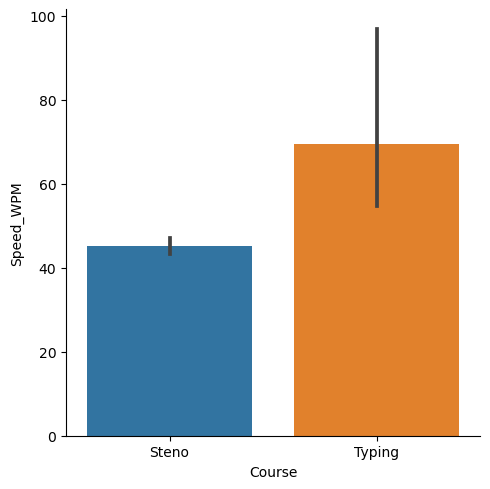

In [22]:
sns.catplot(x='Course',y='Speed_WPM',data=df_rev,kind='bar')
plt.show()

In [23]:
df_clean=df_rev[df_rev['Speed_WPM']<100]

In [24]:
df_clean

,Student_ID,Course,Speed_WPM,Mock_Score
0,101,Steno,45,78
1,102,Typing,52,68
2,103,Steno,48,54
3,104,Typing,55,82
4,105,Steno,42,47
5,106,Typing,60,60
6,107,Steno,47,78
7,108,Typing,58,58
8,109,Steno,41,62
10,111,Steno,46,50


In [29]:
steno_speed=df_clean[df_clean['Course']=='Steno']

In [30]:
steno_speed

,Student_ID,Course,Speed_WPM,Mock_Score
0,101,Steno,45,78
2,103,Steno,48,54
4,105,Steno,42,47
6,107,Steno,47,78
8,109,Steno,41,62
10,111,Steno,46,50
12,113,Steno,49,75
14,115,Steno,43,63


In [27]:
typing_speed=df_clean[df_clean['Course']=='Typing']

In [28]:
typing_speed

,Student_ID,Course,Speed_WPM,Mock_Score
1,102,Typing,52,68
3,104,Typing,55,82
5,106,Typing,60,60
7,108,Typing,58,58
11,112,Typing,54,63
13,114,Typing,57,79


In [31]:
# SciPy library se ttest_ind (Independent T-Test) import kiya
from scipy.stats import ttest_ind

# Yaad rakh: Tere variables dataframe the, hume unke andar ka 'Speed_WPM' column pass karna hai
# Kyunki hum sirf numbers compare kar sakte hain, pura table nahi.

steno_wpm = steno_speed['Speed_WPM']
typing_wpm = typing_speed['Speed_WPM']

# T-Test Run karna (Equal variance false rakhna safe hota hai, isko Welch's t-test bolte hain)
t_stat, p_value = ttest_ind(steno_wpm, typing_wpm, equal_var=False)

print(f"T-Statistic Score: {t_stat}")
print(f"P-Value: {p_value}")

# Decision Logic in Code
alpha = 0.05
if p_value < alpha:
    print("\nDecision: Reject Null Hypothesis (H0).")
    print("Conclusion: Typing aur Steno ki average speed mein significantly fark hai!")
else:
    print("\nDecision: Fail to Reject Null Hypothesis (H0).")
    print("Conclusion: Dono ki speed lagbhag same hai, koi bada fark nahi hai.")

T-Statistic Score: -6.945884429509619
P-Value: 2.5207337828998812e-05

Decision: Reject Null Hypothesis (H0).
Conclusion: Typing aur Steno ki average speed mein significantly fark hai!


### t_stats, P_value 

In [32]:
import pandas as pd
from scipy.stats import ttest_ind, ttest_rel # Ind = Independent, Rel = Paired

data2 = {
    'Student_Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    'Course': ['Steno', 'Steno', 'Steno', 'Steno', 'Typing', 'Typing', 'Typing', 'Typing'],
    'Speed_Month1': [30, 35, 32, 28, 45, 50, 48, 42],
    'Speed_Month3': [40, 42, 45, 38, 55, 65, 60, 52] # 3 mahine baad ki speed
}
df_drill = pd.DataFrame(data2)
print("Data ready for T-Test Drill!")

Data ready for T-Test Drill!


In [33]:
df_drill

,Student_Name,Course,Speed_Month1,Speed_Month3
0,A,Steno,30,40
1,B,Steno,35,42
2,C,Steno,32,45
3,D,Steno,28,38
4,E,Typing,45,55
5,F,Typing,50,65
6,G,Typing,48,60
7,H,Typing,42,52


In [35]:
steno_month1=df_drill[df_drill['Course']=='Steno']

In [36]:
steno_month1

,Student_Name,Course,Speed_Month1,Speed_Month3
0,A,Steno,30,40
1,B,Steno,35,42
2,C,Steno,32,45
3,D,Steno,28,38


In [37]:
typ_month1=df_drill[df_drill['Course']=='Typing']

In [38]:
typ_month1

,Student_Name,Course,Speed_Month1,Speed_Month3
4,E,Typing,45,55
5,F,Typing,50,65
6,G,Typing,48,60
7,H,Typing,42,52


In [40]:
t_stats,p_val=ttest_ind(steno_month1['Speed_Month1'],typ_month1['Speed_Month1'],equal_var=False)
print('The t score :',t_stats)
print('The p_val:',p_val)
alpha=0.05
if p_val<alpha:
    print('Reject Null Hypothesis')
else:
    print('Failed to Reject Null Hypothesis')

The t score : -6.520712004019965
The p_val: 0.0006849124223906539
Reject Null Hypothesis


In [42]:
df_typing= df_drill[df_drill['Course']=='Typing']

In [43]:
df_typing

,Student_Name,Course,Speed_Month1,Speed_Month3
4,E,Typing,45,55
5,F,Typing,50,65
6,G,Typing,48,60
7,H,Typing,42,52


In [44]:
t_test,p_val=ttest_rel(df_typing['Speed_Month1'],df_typing['Speed_Month3'])
print('The t Score is:',t_test)
print('The P_Value is:', p_val)
alpha=0.05
if p_val<0.05:
    print('Reject Null Hypothesis')
else:
    Print('Failed to Reject Null Hypothesis')

The t Score is: -9.945373183606236
The P_Value is: 0.002162829783888144
Reject Null Hypothesis


In [45]:
from scipy.stats import ttest_1samp

# Tera 1 sample data (Maan le JTI ke 8 students ki speed hai)
jti_speeds = [42, 45, 38, 50, 48, 41, 46, 44]

# Fixed Target jisse compare karna hai (National Average)
national_avg = 40

# 1-Sample T-Test ka command
# dhyan de: pehle data pass kiya, fir wo fixed number
t_stat, p_value = ttest_1samp(jti_speeds, national_avg)

print(f"T-Statistic Score: {t_stat}")
print(f"P-Value: {p_value}")

# Decision Logic
alpha = 0.05
if p_value < alpha:
    print("\nDecision: Reject Null Hypothesis (H0).")
    print("Conclusion: JTI students ki speed sach mein national average se alag hai! (You proved it!)")
else:
    print("\nDecision: Fail to Reject Null Hypothesis (H0).")
    print("Conclusion: Speed almost average ke barabar hi hai, koi bada farq nahi hai.")

T-Statistic Score: 3.0963975399031827
P-Value: 0.01741002232152758

Decision: Reject Null Hypothesis (H0).
Conclusion: JTI students ki speed sach mein national average se alag hai! (You proved it!)


In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split # ML ki sabse important library

# 1. JTI Dummy Data for ML
data = {
    'Practice_Hours': [1, 2, 3, 4, 1.5, 2.5, 3.5, 4.5, 2, 3], # Clue 1
    'Mock_Score': [40, 50, 60, 70, 45, 55, 65, 75, 48, 58],   # Clue 2
    'Final_Pass': [0, 0, 1, 1, 0, 1, 1, 1, 0, 1]              # Answer (0=Fail, 1=Pass)
}
df_ml = pd.DataFrame(data)

# 2. X aur y ko alag karna
# X mein sab kuch aayega EXCEPT Final_Pass
X = df_ml.drop('Final_Pass', axis=1) 
# y mein SIRF Final_Pass aayega
y = df_ml['Final_Pass']              

# 3. The 80-20 Split
# random_state=42 ka matlab hai 'time freeze' karna. 
# Agar tu 42 likhega, toh tera aur mera data ek hi tarah se split hoga (randomness fix ho jati hai).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Total Data rows:", len(df_ml))
print("Training Data rows (X_train):", len(X_train))
print("Testing Data rows (X_test):", len(X_test))

Total Data rows: 10
Training Data rows (X_train): 8
Testing Data rows (X_test): 2


In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split # ML ki sabse important library

# 1. JTI Dummy Data for ML
data = {
    'Practice_Hours': [1, 2, 3, 4, 1.5, 2.5, 3.5, 4.5, 2, 3], # Clue 1
    'Mock_Score': [40, 50, 60, 70, 45, 55, 65, 75, 48, 58],   # Clue 2
    'Final_Pass': [0, 0, 1, 1, 0, 1, 1, 1, 0, 1]              # Answer (0=Fail, 1=Pass)
}
df_ml = pd.DataFrame(data)

# 2. X aur y ko alag karna
# X mein sab kuch aayega EXCEPT Final_Pass
X = df_ml.drop('Final_Pass', axis=1) 
# y mein SIRF Final_Pass aayega
y = df_ml['Final_Pass']              

# 3. The 80-20 Split
# random_state=42 ka matlab hai 'time freeze' karna. 
# Agar tu 42 likhega, toh tera aur mera data ek hi tarah se split hoga (randomness fix ho jati hai).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Total Data rows:", len(df_ml))
print("Training Data rows (X_train):", len(X_train))
print("Testing Data rows (X_test):", len(X_test))

Total Data rows: 10
Training Data rows (X_train): 8
Testing Data rows (X_test): 2


In [48]:
X_test

,Practice_Hours,Mock_Score
8,2.0,48
1,2.0,50
